# Coins Images Computer Vision 

Automated coin identification models play a vital role in technology like smart vending systems, currency counters, retail automation, and visual inventory management. Utilizing a streamlined OpenCV workflow offers a transparent and computationally light method for automated object enumeration.

<img src='https://scx2.b-cdn.net/gfx/news/2026/collectible-coins.jpg' width='750'>

In [1]:
#Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# EDA

In [3]:
import pandas as pd, glob, cv2

coins = pd.Series(glob.glob('coin*.png')).map(cv2.imread)

In [4]:
coins

0    [[[255, 255, 255], [255, 255, 255], [255, 255,...
1                                                 None
2    [[[255, 255, 255], [255, 255, 255], [255, 255,...
3    [[[254, 254, 254], [254, 254, 254], [254, 254,...
4    [[[255, 255, 255], [255, 255, 255], [255, 255,...
5    [[[198, 199, 198], [199, 199, 198], [199, 199,...
dtype: object

In [5]:
file_names = coins.index.tolist()
print(file_names)

[0, 1, 2, 3, 4, 5]


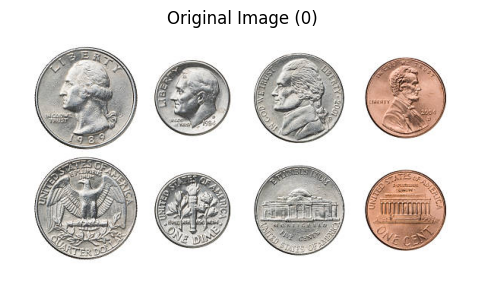

In [7]:
import matplotlib.pyplot as plt
import cv2

image_rgb = cv2.cvtColor(coins.iloc[0], cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title(f"Original Image ({coins.index[0]})")
plt.axis("off")
plt.show()

In [10]:
image_rgb.shape

(317, 612, 3)

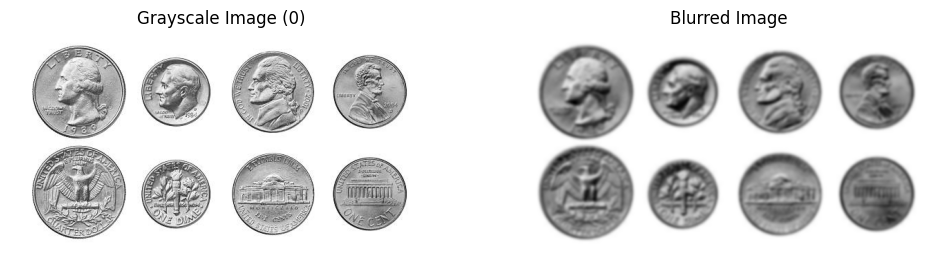

In [11]:
import cv2
import matplotlib.pyplot as plt

# Get the first image from your Pandas Series
image = coins.iloc[0]

# Convert to grayscale and apply Gaussian blur
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (11, 11), 0)

# Display side-by-side plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title(f"Grayscale Image ({coins.index[0]})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")

plt.show()

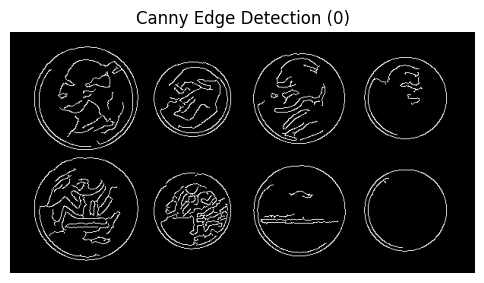

In [12]:
import cv2
import matplotlib.pyplot as plt

# Apply Canny edge detection
edges = cv2.Canny(blur, 30, 150)

# Display the result
plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap='gray')
plt.title(f"Canny Edge Detection ({coins.index[0]})")
plt.axis("off")
plt.show()

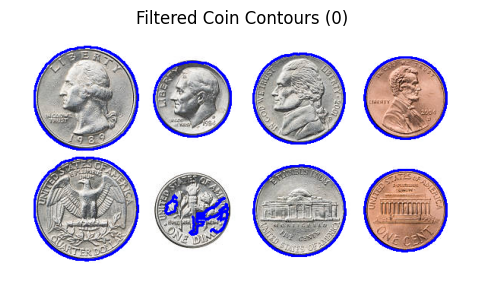

In [15]:
import cv2
import matplotlib.pyplot as plt

# 1. Find contours from the edge-detected image
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 2. Filter out small noise artifacts based on area threshold
coin_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

# 3. Copy the original image from your Pandas Series
filtered_output = coins.iloc[0].copy()

# 4. Draw filtered contours on the image
cv2.drawContours(filtered_output, coin_contours, -1, (255, 0, 0), 2)

# 5. Convert BGR to RGB for Matplotlib visualization
filtered_output_rgb = cv2.cvtColor(filtered_output, cv2.COLOR_BGR2RGB)

# 6. Display the result
plt.figure(figsize=(6, 6))
plt.imshow(filtered_output_rgb)
plt.title(f"Filtered Coin Contours ({coins.index[0]})")
plt.axis("off")
plt.show()

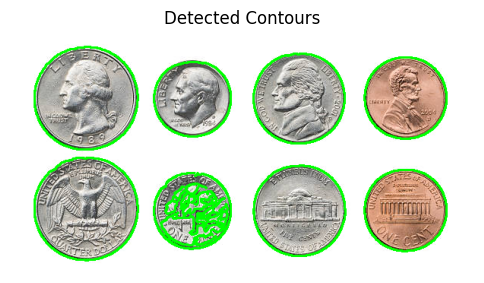

In [16]:
output = image.copy()
cv2.drawContours(output, contours, -1, (0,255,0), 2)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(output_rgb)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

In [17]:
coin_contours = []

for c in contours:
    area = cv2.contourArea(c)
    if area > 150:
        coin_contours.append(c)

print("Detected Coins:", len(coin_contours))

Detected Coins: 8


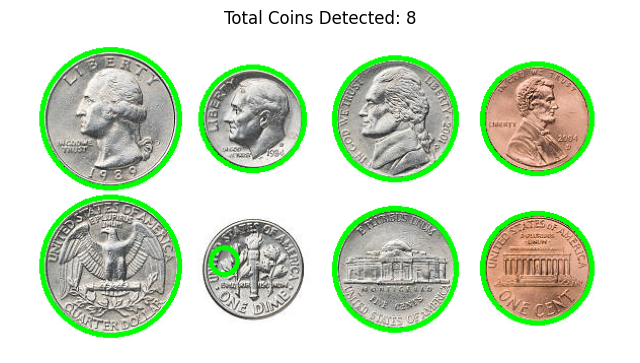

In [18]:
result = image.copy()

for c in coin_contours:
    (x, y), radius = cv2.minEnclosingCircle(c)

    center = (int(x), int(y))
    radius = int(radius)

    cv2.circle(result, center, radius, (0,255,0), 3)

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(result_rgb)
plt.title(f"Total Coins Detected: {len(coin_contours)}")
plt.axis("off")
plt.show()

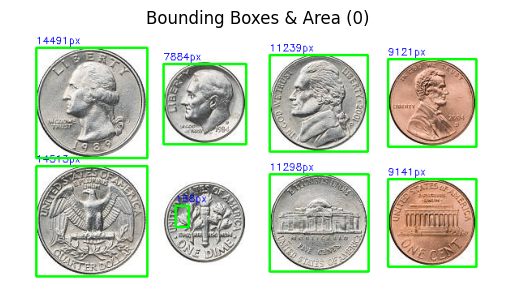

In [20]:
output_boxes = coins.iloc[0].copy()
for cnt in coin_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(output_boxes, f"{int(cv2.contourArea(cnt))}px", (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

plt.imshow(cv2.cvtColor(output_boxes, cv2.COLOR_BGR2RGB))
plt.title(f"Bounding Boxes & Area ({coins.index[0]})")
plt.axis("off")
plt.show()

We built an end-to-end computer vision workflow using OpenCV to automate coin detection and counting. Applying Gaussian blur and Canny edge detection allowed us to extract geometric boundaries, while area thresholding successfully filtered out background noise. Although internal coin engravings logic occasionally generated extra contours, the pipeline consistently yielded precise coin counts, illustrating both the power and constraints of classical image processing.